#Phase 3: Risk Metrics

##1 Imports

In [ ]:
import sys 
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

project_root = Path.cwd().parent 
sys.path.append(str(project_root))


##2 Load Processed Data

In [2]:
data_path = project_root / "data" / "processed" / "daily_returns.csv"
daily_returns = pd.read_csv(
    data_path,
    index_col = 0,
    parse_dates =True
)
daily_returns.head()

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
Date,,,,,,,,
2016-01-05,0.002819,-0.004034,0.001691,0.001729,0.008521,-0.025059,0.004180,0.003538
2016-01-06,0.014441,0.013475,-0.012614,-0.014436,-0.008321,-0.019570,-0.005055,-0.005405
2016-01-07,0.014140,0.001795,-0.023992,-0.040440,-0.016006,-0.042204,-0.011654,-0.016541
2016-01-08,-0.004428,0.004479,-0.010977,-0.022399,-0.020202,0.005288,-0.010683,-0.002643
2016-01-11,-0.008895,-0.010944,0.000990,-0.001528,-0.013388,0.016192,-0.006010,0.001687


##3 Daily Volatility

In [3]:
daily_volatility = daily_returns.std()
daily_volatility.sort_values(ascending = False)

AAPL    0.018216
XOM     0.017608
JPM     0.017263
JNJ     0.011643
KO      0.011446
SPY     0.011218
GLD     0.010233
TLT     0.009290
dtype: float64

##4 Annualized Volatility

In [4]:
annual_volatility = daily_volatility*np.sqrt(252)
annual_volatility.sort_values(ascending = False)

AAPL    0.289163
XOM     0.279524
JPM     0.274041
JNJ     0.184832
KO      0.181695
SPY     0.178086
GLD     0.162449
TLT     0.147469
dtype: float64

In [5]:
annual_volatility_percent = annual_volatility* 100
annual_volatility_percent.sort_values(ascending = False)

AAPL    28.916276
XOM     27.952357
JPM     27.404052
JNJ     18.483175
KO      18.169485
SPY     17.808606
GLD     16.244940
TLT     14.746893
dtype: float64

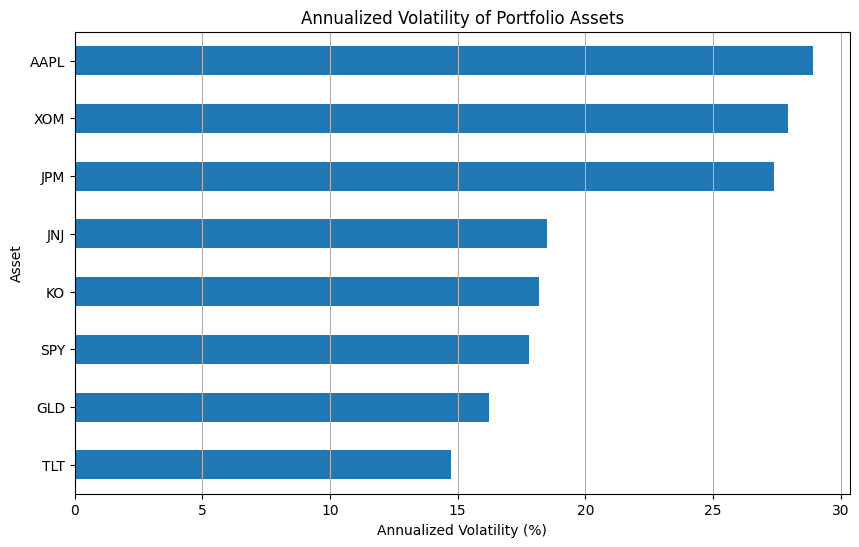

In [6]:
annual_volatility_percent.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Annualized Volatility of Portfolio Assets")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Asset")

plt.grid(axis="x")
plt.show()

##5 Correlation Analysis

In [8]:
correlation_matrix = daily_returns.corr()
correlation_matrix

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
GLD,1.000000,0.259907,0.076342,-0.063801,0.036421,0.035133,0.043699,0.044607
TLT,0.259907,1.000000,-0.155990,-0.307057,-0.237250,-0.092116,-0.086755,-0.071796
SPY,0.076342,-0.155990,1.000000,0.701697,0.486361,0.741368,0.428062,0.491976
JPM,-0.063801,-0.307057,0.701697,1.000000,0.503279,0.407726,0.329744,0.385279
XOM,0.036421,-0.237250,0.486361,0.503279,1.000000,0.277226,0.283460,0.355109
AAPL,0.035133,-0.092116,0.741368,0.407726,0.277226,1.000000,0.289435,0.323400
JNJ,0.043699,-0.086755,0.428062,0.329744,0.283460,0.289435,1.000000,0.494959
KO,0.044607,-0.071796,0.491976,0.385279,0.355109,0.323400,0.494959,1.000000


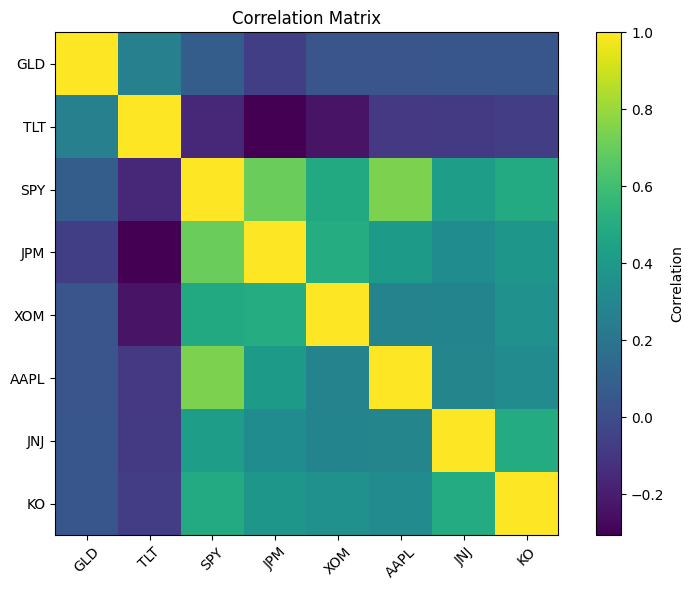

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

##6 Portfolio Volatility

In [ ]:
weights = np.array([1/8]*8)
print(weights)
print(weights.sum())

[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
1.0


In [12]:
portfolio_returns = daily_returns.dot(weights)
portfolio_returns.head()

Date
2016-01-05   -0.000827
2016-01-06   -0.004686
2016-01-07   -0.016863
2016-01-08   -0.007696
2016-01-11   -0.002737
dtype: float64

In [13]:
portfolio_daily_volatility = portfolio_returns.std()
print(portfolio_daily_volatility)

0.007925446460830933


In [14]:
portfolio_annual_volatility = portfolio_daily_volatility * np.sqrt(252)

print(f"Portfolio Annual Volatility: {portfolio_annual_volatility:.2%}")

Portfolio Annual Volatility: 12.58%


##7 Beta

In [15]:
market_returns = daily_returns["SPY"]


In [16]:
betas = {}

In [17]:
for asset in daily_returns.columns:
    covariance = daily_returns[asset].cov(market_returns)
    market_variance = market_returns.var()

    beta = covariance/market_variance 
    betas[asset] = beta 

In [ ]:
beta_series = pd.Series(betas)
beta_series.sort_values(ascending = False)

AAPL    1.203777
JPM     1.079777
SPY     1.000000
XOM     0.763391
KO      0.501946
JNJ     0.444277
GLD     0.069639
TLT    -0.129171
dtype: float64